
# Workshop-MBRL: Train a Transition Model and Plan With It

**Goal:** Train a neural transition model $\hat{s}_{t+1}=f_\psi(s_t,a_t)$, then use **random-shooting MPC** to control a 2D point robot to a goal.

This workshop is prepared with the help of chatGPT.


## Imports and setup

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Environment: 2D point robot with one obstacle

In [2]:

class PointRobot2D:
    def __init__(self):
        self.dt = 0.1
        self.max_steps = 120
        self.goal = np.array([1.5, 1.5], dtype=np.float32)
        self.obs = np.array([0.2, 1.0, 0.4, 1.1], dtype=np.float32)  # [xmin,xmax,ymin,ymax]
        self.reset()

    def reset(self):
        self.t = 0
        self.state = np.array([-1.3, -1.2, 0.0, 0.0], dtype=np.float32)
        return self.state.copy()

    def _in_obstacle(self, p):
        x, y = p
        xmin, xmax, ymin, ymax = self.obs
        return (xmin <= x <= xmax) and (ymin <= y <= ymax)

    def step(self, action):
        a = np.clip(action.astype(np.float32), -1.0, 1.0)
        x, y, vx, vy = self.state
        dt = self.dt

        # Hidden disturbance region (source of model mismatch if data is sparse)
        disturb = np.zeros(2, dtype=np.float32)
        if 0.0 < x < 1.1 and 0.2 < y < 1.2:
            disturb = np.array([0.10, -0.05], dtype=np.float32)

        vx = 0.92 * vx + 0.35 * a[0] + disturb[0]
        vy = 0.92 * vy + 0.35 * a[1] + disturb[1]
        x = x + dt * vx
        y = y + dt * vy
        self.state = np.array([x, y, vx, vy], dtype=np.float32)
        self.t += 1

        pos = self.state[:2]
        dist = np.linalg.norm(pos - self.goal)
        collision = self._in_obstacle(pos)
        reward = -dist - 0.02 * np.sum(a**2) - (5.0 if collision else 0.0)

        done = False
        success = dist < 0.18
        if success:
            reward += 10.0
            done = True
        if collision or self.t >= self.max_steps:
            done = True

        return self.state.copy(), float(reward), done, {"collision": collision, "success": success}

def plot_env(ax, env):
    xmin, xmax, ymin, ymax = env.obs
    ax.add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, alpha=0.3))
    ax.scatter([env.goal[0]], [env.goal[1]], marker='*', s=220)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.grid(True)


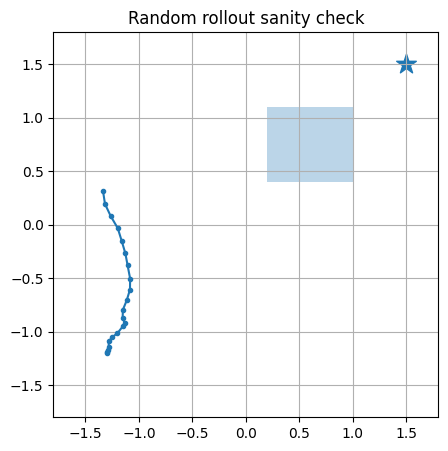

In [3]:

env = PointRobot2D()
s = env.reset()
traj = [s.copy()]
for _ in range(20):
    a = np.random.uniform(-1, 1, size=2).astype(np.float32)
    s, _, done, _ = env.step(a)
    traj.append(s.copy())
    if done:
        break
traj = np.array(traj)

fig, ax = plt.subplots(figsize=(5,5))
plot_env(ax, env)
ax.plot(traj[:,0], traj[:,1], '-o', ms=3)
ax.set_title('Random rollout sanity check')
plt.show()


## Part 1: Collect a dataset of transitions

In [5]:

# TODO_COLLECT
def collect_dataset(env, n_steps=3000):
    data = []
    s = env.reset()
    for _ in range(n_steps):
        # TODO: sample random action in [-1,1]^2
        # Be careful about the action dimension
        a = None

        s_next, r, done, info = env.step(a)
        data.append((s.copy(), a.copy(), s_next.copy()))
        s = s_next
        if done:
            s = env.reset()
    return data

data = collect_dataset(env, n_steps=3000)
print('Collected transitions:', len(data))


AttributeError: 'NoneType' object has no attribute 'astype'

## Part 2: Train a transition model

In [ ]:

states = np.stack([d[0] for d in data]).astype(np.float32)
actions = np.stack([d[1] for d in data]).astype(np.float32)
next_states = np.stack([d[2] for d in data]).astype(np.float32)

X = np.concatenate([states, actions], axis=1)
Y = next_states - states

idx = np.arange(len(X)); np.random.shuffle(idx)
split = int(0.8 * len(X))
tr, va = idx[:split], idx[split:]

Xtr = torch.tensor(X[tr], device=device)
Ytr = torch.tensor(Y[tr], device=device)
Xva = torch.tensor(X[va], device=device)
Yva = torch.tensor(Y[va], device=device)
print(Xtr.shape, Ytr.shape)


In [ ]:

class TransitionModel(nn.Module):
    def __init__(self, in_dim=6, out_dim=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))

model = TransitionModel().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:

# TODO_TRAIN
batch_size = 128
epochs = 20

for ep in range(epochs):
    perm = torch.randperm(Xtr.shape[0], device=device)
    losses = []
    model.train()
    for i in range(0, Xtr.shape[0], batch_size):
        bi = perm[i:i+batch_size]
        xb = Xtr[bi]
        yb = Ytr[bi]
        s_b = xb[:, :4]
        a_b = xb[:, 4:]

        # TODO: forward pass
        pred = None

        # TODO: MSE loss
        loss = None

        # TODO: optimizer step
        # opt.zero_grad(); loss.backward(); opt.step()

        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        pred_v = model(Xva[:, :4], Xva[:, 4:])
        val_loss = ((pred_v - Yva)**2).mean().item()
    if (ep + 1) % 5 == 0:
        print(f"Epoch {ep+1:02d} | train {np.mean(losses):.5f} | val {val_loss:.5f}")


## Part 3: Roll out the learned model (imagined trajectories)

In [ ]:

# TODO_ROLLOUT
@torch.no_grad()
def rollout_model(model, s0, action_seq):
    states = [s0.copy()]
    s = torch.tensor(s0[None], dtype=torch.float32, device=device)
    for a in action_seq:
        a_t = torch.tensor(a[None], dtype=torch.float32, device=device)
        # TODO: predict delta and update state
        ds = None
        s = None
        states.append(s.squeeze(0).cpu().numpy().copy())
    return np.array(states)

A = np.random.uniform(-1, 1, size=(10,2)).astype(np.float32)
imag = rollout_model(model, env.reset(), A)
print("Imagined rollout shape:", imag.shape)


## Part 4: Random-shooting planner (MPC-style)

In [ ]:

def collision_check_positions(pos_traj, env):
    xmin, xmax, ymin, ymax = env.obs
    x, y = pos_traj[:,0], pos_traj[:,1]
    return ((x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax))

# TODO_SCORE
def score_rollout(imag_states, action_seq, env):
    pos = imag_states[:, :2]
    goal = env.goal[None]
    # TODO: higher is better. Include:
    #   - negative distance-to-goal along rollout
    #   - small action penalty
    #   - big penalty for any imagined collision
    score = 0.0
    return float(score)

def plan_random_shooting(model, s0, env, H=12, N=200):
    best_score, best_A = -1e18, None
    for _ in range(N):
        A = np.random.uniform(-1, 1, size=(H,2)).astype(np.float32)
        imag = rollout_model(model, s0, A)
        sc = score_rollout(imag, A, env)
        if sc > best_score:
            best_score, best_A = sc, A
    return best_A, best_score


In [ ]:

# TODO_MPC
def run_mpc_episode(env, model, H=12, N=200, max_steps=80):
    s = env.reset()
    real_states = [s.copy()]
    imagined_chunks = []
    last_info = {}

    for t in range(max_steps):
        # TODO: plan from current state
        best_A, _ = None, None
        imag = None
        imagined_chunks.append(imag)

        # TODO: execute only first action in real env
        a0 = None
        s, r, done, info = env.step(a0)
        last_info = info
        real_states.append(s.copy())
        if done:
            break

    return {"real_states": np.array(real_states), "imagined_chunks": imagined_chunks, "info": last_info}

result = run_mpc_episode(env, model, H=12, N=200, max_steps=80)
print("Final info:", result["info"], "Steps:", len(result["real_states"]) - 1)


In [ ]:

fig, ax = plt.subplots(figsize=(6,6))
plot_env(ax, env)
real = result["real_states"]
ax.plot(real[:,0], real[:,1], '-o', ms=3, label='real')
for imag in result["imagined_chunks"][::5]:
    if imag is not None:
        ax.plot(imag[:,0], imag[:,1], '--', alpha=0.4)
ax.legend()
ax.set_title("MPC with learned transition model")
plt.show()


## Part 5: Compare horizons (compounding error)

In [ ]:

# TODO_HORIZON_COMPARE
settings = [6, 20]
results = {}

for H in settings:
    # TODO: run one episode for each horizon
    pass

# TODO: print success/collision and optionally plot both trajectories
